# Thesis Case Study  
## Predictive Performance vs Economic Value in ML-Based Stock Selection

This notebook implements a simple but robust empirical case study for a thesis on machine learning in financial markets.

The objective is to compare:

- **Predictive performance**, measured through cross-sectional ranking metrics such as Rank IC;
- **Economic value**, measured through portfolio returns net of transaction costs.

The same predictive model is used to generate stock rankings, while different portfolio implementation rules are compared to show how turnover and trading frictions affect realized economic value.

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

/Users/gabriele/thesis_ml_backtest/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [5]:
# ============================================================
# PARAMETERS
# ============================================================

tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META",
    "NVDA","JPM","V","XOM","UNH",
    "HD","MA","PFE","BAC","KO",
    "DIS","CSCO","PEP","ADBE","CMCSA"
]

start_date = "2010-01-01"
end_date   = "2025-01-01"

train_months = 60
top_q = 0.20
rf_annual = 0.01

# Main transaction cost assumption
base_cost = 0.002  # 0.2% per side

# Sensitivity analysis
cost_grid = [0.001, 0.002, 0.003]

In [6]:
display(Markdown("## 1. Data download"))

data_raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    progress=False
)

if isinstance(data_raw.columns, pd.MultiIndex):
    prices_daily = data_raw["Close"].copy()
else:
    prices_daily = data_raw.copy()

prices_daily = prices_daily.dropna(axis=1, how="any")

print(f"Number of stocks retained: {prices_daily.shape[1]}")
print(f"Number of daily observations: {prices_daily.shape[0]}")

prices_daily.head()

## 1. Data download

Number of stocks retained: 19
Number of daily observations: 3774


Ticker,AAPL,ADBE,AMZN,BAC,CMCSA,CSCO,DIS,GOOGL,HD,JPM,KO,MA,MSFT,NVDA,PEP,PFE,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,
2010-01-04,6.406481,37.090000,6.6950,12.100780,5.515411,15.889603,27.291225,15.555865,19.441814,28.279211,17.316332,23.542099,23.077385,0.423784,37.626457,9.051420,24.407692,19.564671,37.377274
2010-01-05,6.417558,37.700001,6.7345,12.494114,5.440659,15.818802,27.223150,15.487362,19.584217,28.826963,17.106861,23.472439,23.084841,0.429972,38.081131,8.922322,24.368980,19.340479,37.523216
2010-01-06,6.315475,37.619999,6.6125,12.640648,5.401658,15.715836,27.078482,15.096945,19.516405,28.985361,17.100798,23.438496,22.943174,0.432722,37.700195,8.893635,24.608961,19.080765,37.847530
2010-01-07,6.303803,36.889999,6.5000,13.057119,5.515411,15.786629,27.086990,14.745497,19.746969,29.559519,17.058287,23.285339,22.704563,0.424242,37.460579,8.860162,25.553373,19.258347,37.728607
2010-01-08,6.345712,36.689999,6.6760,12.941433,5.499160,15.870293,27.129541,14.942070,19.652033,29.486921,16.742565,23.293600,22.861151,0.425159,37.337700,8.931883,25.313400,19.311623,37.577290


In [7]:
display(Markdown("## 2. Monthly prices and returns"))

prices_m = prices_daily.resample("ME").last()
rets_m = prices_m.pct_change()

print("Monthly price matrix shape:", prices_m.shape)
prices_m.head()

## 2. Monthly prices and returns

Monthly price matrix shape: (180, 19)


Ticker,AAPL,ADBE,AMZN,BAC,CMCSA,CSCO,DIS,GOOGL,HD,JPM,KO,MA,MSFT,NVDA,PEP,PFE,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,
2010-01-31,5.749398,32.299999,6.2705,11.707446,5.144900,14.460883,25.146732,13.153050,18.994253,25.698767,16.469336,22.919395,21.011972,0.352733,36.631126,8.922322,25.545630,18.208418,34.825989
2010-02-28,6.125387,34.650002,5.9200,12.848885,5.343159,15.657912,26.584913,13.075117,21.157476,27.698448,16.004858,20.577940,21.477301,0.371298,38.382198,8.470821,26.211367,18.958296,35.363300
2010-03-31,7.034824,35.369999,6.7885,13.775025,6.119929,16.751976,29.708038,14.075853,22.100510,29.533119,16.833679,23.295422,21.941755,0.398802,40.938114,8.277751,25.290180,20.236544,36.440529
2010-04-30,7.815842,33.599998,6.8550,13.759595,6.457966,17.331181,31.350445,13.047815,24.068031,28.132442,16.359272,22.762005,22.878160,0.360067,40.356476,8.070206,23.484844,20.058704,36.870312
2010-05-31,7.689811,32.080002,6.2730,12.146723,5.909188,14.904943,28.440065,12.053283,23.132090,26.150366,15.731844,18.515926,19.414537,0.301164,38.914711,7.428504,22.524059,16.132284,33.116695


In [8]:
display(Markdown("## 3. Feature engineering"))

# All features are lagged by one month to reduce look-ahead concerns

mom_12_1 = ((prices_m.shift(1) / prices_m.shift(12)) - 1)
vol_6m   = rets_m.shift(1).rolling(6).std()
p_to_52w = prices_m.shift(1) / prices_m.shift(1).rolling(12).max()
size_log = np.log(prices_m.shift(1))

# Additional simple lagged features for robustness
mom_3_1  = ((prices_m.shift(1) / prices_m.shift(3)) - 1)
rev_1m   = rets_m.shift(1)

# Forward return target
fwd_ret_1m = rets_m.shift(-1)

panel_list = []

for col in prices_m.columns:
    df_tmp = pd.DataFrame({
        "date": prices_m.index,
        "ticker": col,
        "fwd_ret_1m": fwd_ret_1m[col].values,
        "mom_12_1": mom_12_1[col].values,
        "mom_3_1": mom_3_1[col].values,
        "vol_6m": vol_6m[col].values,
        "p_to_52w": p_to_52w[col].values,
        "size_log": size_log[col].values,
        "rev_1m": rev_1m[col].values
    })
    panel_list.append(df_tmp)

panel = pd.concat(panel_list, ignore_index=True).dropna()

print(f"Panel rows: {len(panel)}")
panel.head()

## 3. Feature engineering

Panel rows: 3173


,date,ticker,fwd_ret_1m,mom_12_1,mom_3_1,vol_6m,p_to_52w,size_log,rev_1m
12,2011-01-31,AAPL,0.040935,0.679475,0.071699,0.071934,1.000000,2.267577,0.036671
13,2011-02-28,AAPL,-0.013307,0.658294,0.090535,0.071163,1.000000,2.318231,0.051959
14,2011-03-31,AAPL,0.004649,0.503022,0.095021,0.050974,1.000000,2.358350,0.040935
15,2011-04-30,AAPL,-0.006569,0.334827,0.027083,0.025777,0.986693,2.344954,-0.013307
16,2011-05-31,AAPL,-0.034960,0.363011,-0.008720,0.024787,0.991280,2.349592,0.004649


In [9]:
display(Markdown("## 4. Rolling Random Forest estimation"))

feature_cols = ["mom_12_1", "mom_3_1", "vol_6m", "p_to_52w", "size_log", "rev_1m"]
dates = sorted(panel["date"].unique())

pred_list = []

for i, current_date in enumerate(dates):
    cutoff = current_date - pd.DateOffset(months=train_months)

    train = panel[(panel["date"] >= cutoff) & (panel["date"] < current_date)]
    test  = panel[panel["date"] == current_date]

    if len(train) < 200 or len(test) == 0:
        continue

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    )

    rf.fit(train[feature_cols], train["fwd_ret_1m"])
    pred = rf.predict(test[feature_cols])

    tmp = test[["date", "ticker", "fwd_ret_1m"]].copy()
    tmp["pred"] = pred
    pred_list.append(tmp)

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(dates)} months")

pred_df = pd.concat(pred_list, ignore_index=True)

print(f"Predictions generated: {len(pred_df)}")
pred_df.head()

## 4. Rolling Random Forest estimation

Processed 20/167 months
Processed 40/167 months
Processed 60/167 months
Processed 80/167 months
Processed 100/167 months
Processed 120/167 months
Processed 140/167 months
Processed 160/167 months
Predictions generated: 2964


,date,ticker,fwd_ret_1m,pred
0,2011-12-31,AAPL,0.127111,-0.001611
1,2011-12-31,ADBE,0.094800,-0.008635
2,2011-12-31,AMZN,0.123281,0.005235
3,2011-12-31,BAC,0.282374,-0.070481
4,2011-12-31,CMCSA,0.121046,-0.000011


In [10]:
display(Markdown("## 5. Predictive performance"))

ic_list = []

for d in sorted(pred_df["date"].unique()):
    df_d = pred_df[pred_df["date"] == d]
    if len(df_d) > 5:
        rank_ic = df_d["pred"].corr(df_d["fwd_ret_1m"], method="spearman")
        ic_list.append({"date": d, "rank_ic": rank_ic})

ic_df = pd.DataFrame(ic_list)

mean_ic = ic_df["rank_ic"].mean()
std_ic  = ic_df["rank_ic"].std()
ic_ir   = mean_ic / std_ic if std_ic != 0 else np.nan
hit_rate = (ic_df["rank_ic"] > 0).mean() * 100

predictive_table = pd.DataFrame({
    "Metric": ["Mean Rank IC", "Std Rank IC", "IC Information Ratio", "Hit Rate (%)"],
    "Value": [mean_ic, std_ic, ic_ir, hit_rate]
}).round(4)

display(predictive_table)

## 5. Predictive performance

,Metric,Value
0,Mean Rank IC,-0.0129
1,Std Rank IC,0.2588
2,IC Information Ratio,-0.0499
3,Hit Rate (%),46.1538


In [11]:
display(Markdown("## 6. Portfolio weights"))

panel_pred = pred_df.copy()
all_dates = sorted(panel_pred["date"].unique())
tickers_u = sorted(panel_pred["ticker"].unique())

def target_weights(df_date, top_q=0.20):
    df = df_date.sort_values("pred", ascending=False)
    k = max(1, int(np.floor(len(df) * top_q)))

    w = pd.Series(0.0, index=df["ticker"])
    w.iloc[:k] = 1.0 / k

    return w.reindex(tickers_u).fillna(0.0)

weights_target = {
    d: target_weights(panel_pred[panel_pred["date"] == d], top_q=top_q)
    for d in all_dates
}

rets_wide = panel_pred.pivot(index="date", columns="ticker", values="fwd_ret_1m").reindex(all_dates)

rets_wide.head()

## 6. Portfolio weights

ticker,AAPL,ADBE,AMZN,BAC,CMCSA,CSCO,DIS,GOOGL,HD,JPM,KO,MA,MSFT,NVDA,PEP,PFE,UNH,V,XOM
date,,,,,,,,,,,,,,,,,,,
2011-12-31,0.127111,0.094800,0.123281,0.282374,0.121046,0.090455,0.037333,-0.101858,0.055899,0.129879,-0.034872,-0.045867,0.137519,0.065657,-0.010248,-0.011091,0.021902,-0.008765,-0.012034
2012-01-31,0.188311,0.062682,-0.075859,0.119191,0.106471,0.011705,0.079435,0.065746,0.071638,0.052011,0.034503,0.181202,0.081915,0.025728,-0.033713,-0.002361,0.076463,0.158511,0.038613
2012-02-29,0.105283,0.043174,0.126996,0.200752,0.020401,0.063883,0.042629,0.037186,0.064112,0.171764,0.067163,0.001286,0.016383,0.016502,0.054178,0.071936,0.060320,0.014007,0.002659
2012-03-31,-0.025969,-0.022151,0.145129,-0.152560,0.016853,-0.043197,-0.015304,-0.056749,0.029417,-0.059127,0.031212,0.076187,-0.007440,-0.155845,-0.005275,0.011037,-0.047336,0.042203,-0.004497
2012-04-30,-0.010702,-0.074516,-0.081889,-0.092491,-0.047447,-0.189980,0.060311,-0.039663,-0.041685,-0.228711,-0.020833,-0.101178,-0.082400,-0.043846,0.036070,-0.035514,-0.006767,-0.061492,-0.083024


In [12]:
display(Markdown("## 7. Backtest functions"))

def run_strategy(weights_target, rets_wide, cost_per_trade=0.002, mode="A", freq=3, lam=0.3):
    prev_w = pd.Series(0.0, index=rets_wide.columns)
    rets_list = []
    to_list = []

    for i, d in enumerate(all_dates):
        wt = weights_target[d]

        if mode == "A":
            w = wt
        elif mode == "B":
            w = wt if i % freq == 0 else prev_w
        elif mode == "C":
            w = (1 - lam) * prev_w + lam * wt
        else:
            raise ValueError("Invalid mode")

        turnover = (w - prev_w).abs().sum()
        r_gross = (w * rets_wide.loc[d]).sum()
        r_net = r_gross - turnover * cost_per_trade

        rets_list.append((r_gross, r_net))
        to_list.append(turnover)
        prev_w = w

    rets_df = pd.DataFrame(rets_list, index=all_dates, columns=["gross", "net"])
    to_sr = pd.Series(to_list, index=all_dates)

    return rets_df, to_sr


def compute_stats(rets_df, to_sr, rf_annual=0.01):
    rf_m = (1 + rf_annual)**(1/12) - 1
    out = {}

    for col in ["gross", "net"]:
        r = rets_df[col].dropna()

        ann_ret = (1 + r.mean())**12 - 1
        ann_vol = r.std() * np.sqrt(12)
        excess = r - rf_m
        sharpe = excess.mean() / excess.std() * np.sqrt(12)

        cum = (1 + r).cumprod()
        running_max = cum.cummax()
        dd = (cum - running_max) / running_max
        max_dd = dd.min()

        out[col] = {
            "ann_return": ann_ret * 100,
            "ann_vol": ann_vol * 100,
            "sharpe": sharpe,
            "max_drawdown": max_dd * 100
        }

    out["avg_turnover"] = to_sr.mean()
    return out

## 7. Backtest functions

In [13]:
display(Markdown("## 8. Strategy simulation"))

rets_A, to_A = run_strategy(weights_target, rets_wide, cost_per_trade=base_cost, mode="A")
rets_B, to_B = run_strategy(weights_target, rets_wide, cost_per_trade=base_cost, mode="B", freq=3)
rets_C, to_C = run_strategy(weights_target, rets_wide, cost_per_trade=base_cost, mode="C", lam=0.3)

sA = compute_stats(rets_A, to_A, rf_annual=rf_annual)
sB = compute_stats(rets_B, to_B, rf_annual=rf_annual)
sC = compute_stats(rets_C, to_C, rf_annual=rf_annual)

summary = pd.DataFrame({
    "Strategy A - Monthly": [
        sA["gross"]["ann_return"], sA["net"]["ann_return"],
        sA["gross"]["sharpe"], sA["net"]["sharpe"],
        sA["gross"]["max_drawdown"], sA["avg_turnover"]
    ],
    "Strategy B - Quarterly": [
        sB["gross"]["ann_return"], sB["net"]["ann_return"],
        sB["gross"]["sharpe"], sB["net"]["sharpe"],
        sB["gross"]["max_drawdown"], sB["avg_turnover"]
    ],
    "Strategy C - Smoothing": [
        sC["gross"]["ann_return"], sC["net"]["ann_return"],
        sC["gross"]["sharpe"], sC["net"]["sharpe"],
        sC["gross"]["max_drawdown"], sC["avg_turnover"]
    ]
}, index=[
    "Annual return gross (%)",
    "Annual return net (%)",
    "Sharpe gross",
    "Sharpe net",
    "Max drawdown gross (%)",
    "Average turnover"
]).round(4)

display(summary)

## 8. Strategy simulation

,Strategy A - Monthly,Strategy B - Quarterly,Strategy C - Smoothing
Annual return gross (%),24.7604,29.8936,27.9742
Annual return net (%),20.7201,28.3831,26.6894
Sharpe gross,0.9791,1.1808,1.2476
Sharpe net,0.8249,1.1264,1.1939
Max drawdown gross (%),-33.7004,-29.4000,-28.4983
Average turnover,1.3953,0.4979,0.4290


In [14]:
display(Markdown("## 9. Transaction cost sensitivity"))

rows = []

for c in cost_grid:
    rA, tA = run_strategy(weights_target, rets_wide, cost_per_trade=c, mode="A")
    rB, tB = run_strategy(weights_target, rets_wide, cost_per_trade=c, mode="B", freq=3)
    rC, tC = run_strategy(weights_target, rets_wide, cost_per_trade=c, mode="C", lam=0.3)

    sA_c = compute_stats(rA, tA, rf_annual=rf_annual)
    sB_c = compute_stats(rB, tB, rf_annual=rf_annual)
    sC_c = compute_stats(rC, tC, rf_annual=rf_annual)

    rows.append(["A", c, sA_c["net"]["ann_return"], sA_c["net"]["sharpe"]])
    rows.append(["B", c, sB_c["net"]["ann_return"], sB_c["net"]["sharpe"]])
    rows.append(["C", c, sC_c["net"]["ann_return"], sC_c["net"]["sharpe"]])

cost_sensitivity = pd.DataFrame(rows, columns=["Strategy", "Cost per side", "Net ann. return (%)", "Net Sharpe"]).round(4)
display(cost_sensitivity)

## 9. Transaction cost sensitivity

,Strategy,Cost per side,Net ann. return (%),Net Sharpe
0,A,0.001,22.7250,0.9020
1,B,0.001,29.1363,1.1537
2,C,0.001,27.3303,1.2208
3,A,0.002,20.7201,0.8249
4,B,0.002,28.3831,1.1264
5,C,0.002,26.6894,1.1939
6,A,0.003,18.7453,0.7478
7,B,0.003,27.6339,1.0989
8,C,0.003,26.0514,1.1670


In [15]:
display(Markdown("## 10. Benchmark comparison"))

spy = yf.download("SPY", start=start_date, end=end_date, interval="1d", auto_adjust=True, progress=False)

if isinstance(spy.columns, pd.MultiIndex):
    spy_close = spy["Close"].copy()
else:
    spy_close = spy.copy()

spy_m = spy_close.resample("ME").last()
spy_ret = spy_m.pct_change().dropna()

spy_ret = spy_ret.loc[spy_ret.index.intersection(rets_A.index)]

def benchmark_stats(r, rf_annual=0.01):
    rf_m = (1 + rf_annual)**(1/12) - 1

    ann_ret = (1 + r.mean())**12 - 1
    ann_vol = r.std() * np.sqrt(12)
    excess = r - rf_m
    sharpe = excess.mean() / excess.std() * np.sqrt(12)

    cum = (1 + r).cumprod()
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    max_dd = dd.min()

    return {
        "ann_return": float(ann_ret * 100),
        "ann_vol": float(ann_vol * 100),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd * 100)
    }

spy_stats = benchmark_stats(spy_ret.squeeze(), rf_annual=rf_annual)

benchmark_table = pd.DataFrame({
    "Portfolio": ["Strategy A Net", "Strategy B Net", "Strategy C Net", "SPY"],
    "Annual return (%)": [
        sA["net"]["ann_return"],
        sB["net"]["ann_return"],
        sC["net"]["ann_return"],
        spy_stats["ann_return"]
    ],
    "Annual vol (%)": [
        sA["net"]["ann_vol"],
        sB["net"]["ann_vol"],
        sC["net"]["ann_vol"],
        spy_stats["ann_vol"]
    ],
    "Sharpe": [
        sA["net"]["sharpe"],
        sB["net"]["sharpe"],
        sC["net"]["sharpe"],
        spy_stats["sharpe"]
    ],
    "Max drawdown (%)": [
        sA["net"]["max_drawdown"],
        sB["net"]["max_drawdown"],
        sC["net"]["max_drawdown"],
        spy_stats["max_drawdown"]
    ]
}).round(4)

display(benchmark_table)

## 10. Benchmark comparison

,Portfolio,Annual return (%),Annual vol (%),Sharpe,Max drawdown (%)
0,Strategy A Net,20.7201,21.8003,0.8249,-34.2036
1,Strategy B Net,28.3831,21.5302,1.1264,-29.5107
2,Strategy C Net,26.6894,19.1782,1.1939,-28.6615
3,SPY,16.0815,14.0974,0.9938,-23.9272


## 11. Equity curves

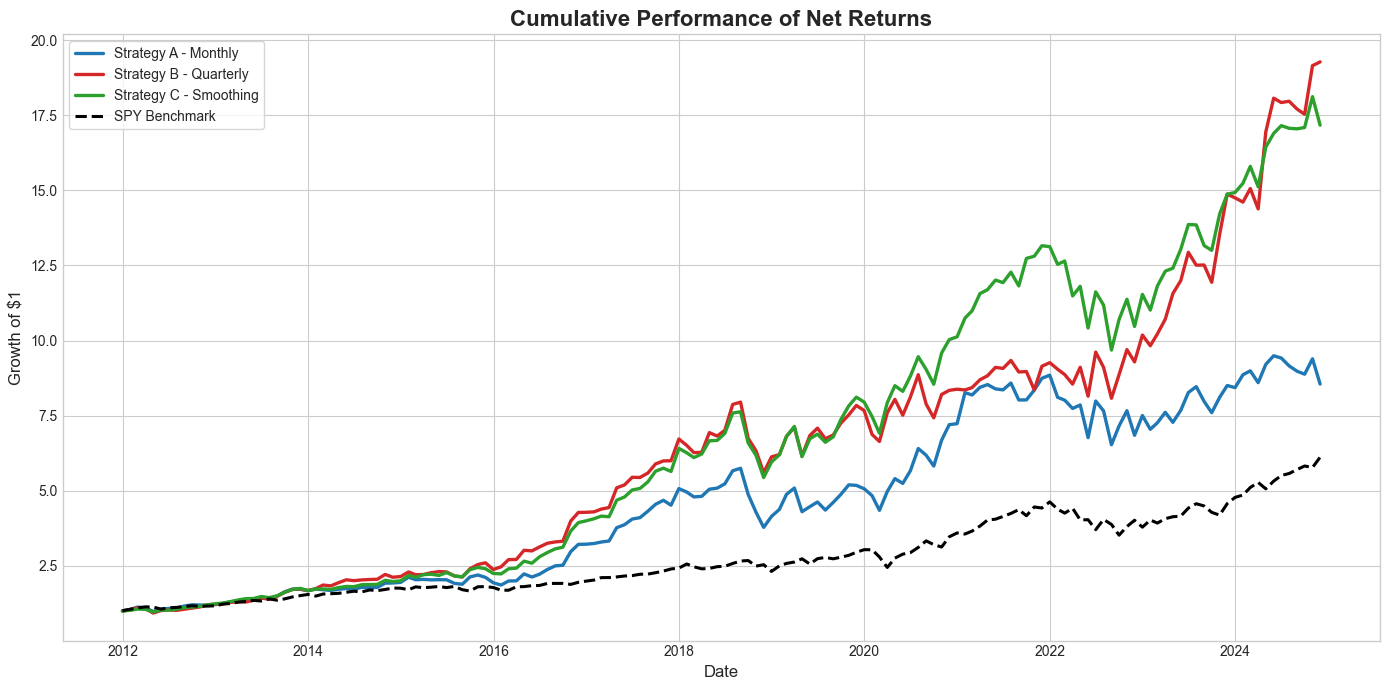

In [16]:
display(Markdown("## 11. Equity curves"))

equity_A = (1 + rets_A["net"]).cumprod()
equity_B = (1 + rets_B["net"]).cumprod()
equity_C = (1 + rets_C["net"]).cumprod()
equity_SPY = (1 + spy_ret.squeeze()).cumprod()

plt.figure(figsize=(14, 7))

plt.plot(equity_A.index, equity_A.values, label="Strategy A - Monthly", linewidth=2.4, color="#1f77b4")
plt.plot(equity_B.index, equity_B.values, label="Strategy B - Quarterly", linewidth=2.4, color="#d62728")
plt.plot(equity_C.index, equity_C.values, label="Strategy C - Smoothing", linewidth=2.4, color="#2ca02c")
plt.plot(equity_SPY.index, equity_SPY.values, label="SPY Benchmark", linewidth=2.2, color="black", linestyle="--")

plt.title("Cumulative Performance of Net Returns", fontsize=16, weight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

Figure 1: Cumulative Performance of Net Returns (2010-2024)

Growth of $1 invested in January 2010 for the three ML-based strategies and the S&P 500 benchmark. All strategies use identical predictive signals but differ in implementation (rebalancing frequency and turnover management). Net returns include transaction costs of 0.2% per side. Strategy B (quarterly rebalancing) achieves the highest cumulative return despite lower adherence to monthly signals, demonstrating the economic impact of turnover management.


## 12. Drawdown comparison

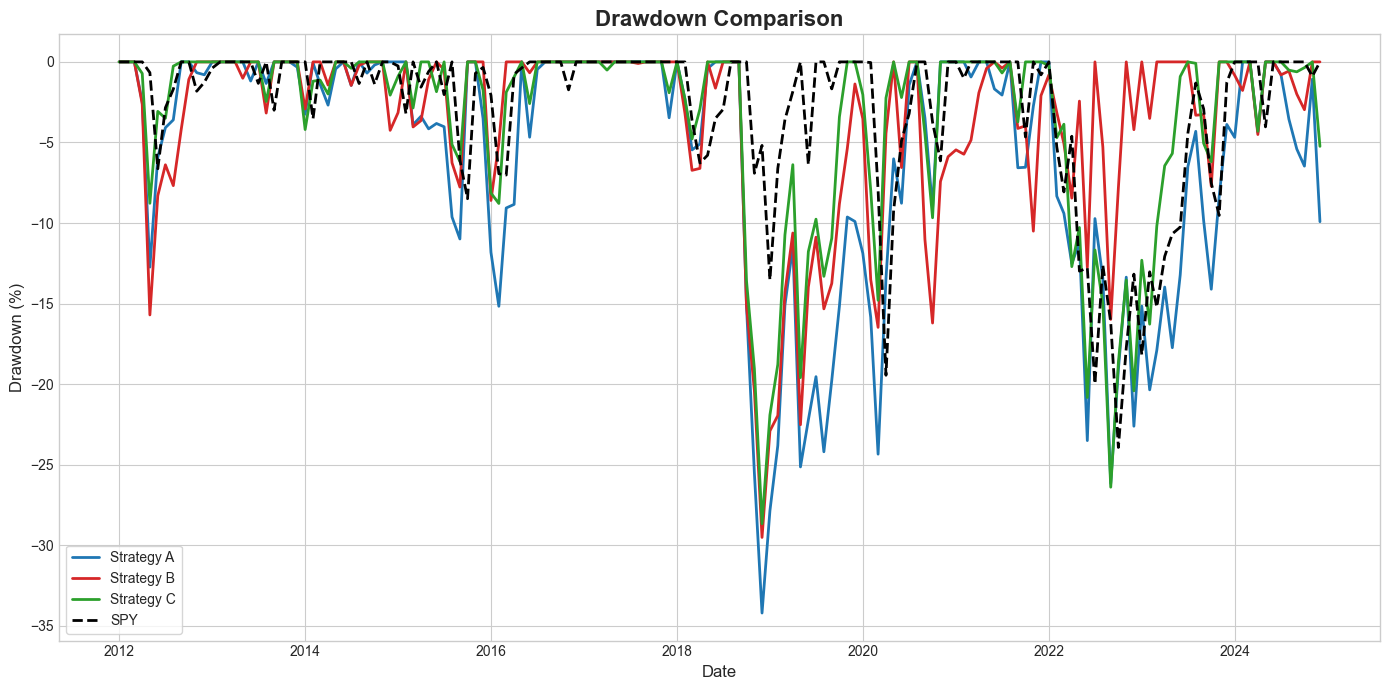

In [17]:
display(Markdown("## 12. Drawdown comparison"))

def drawdown_series(r):
    cum = (1 + r).cumprod()
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    return dd * 100

dd_A = drawdown_series(rets_A["net"])
dd_B = drawdown_series(rets_B["net"])
dd_C = drawdown_series(rets_C["net"])
dd_SPY = drawdown_series(spy_ret.squeeze())

plt.figure(figsize=(14, 7))

plt.plot(dd_A.index, dd_A.values, label="Strategy A", linewidth=2, color="#1f77b4")
plt.plot(dd_B.index, dd_B.values, label="Strategy B", linewidth=2, color="#d62728")
plt.plot(dd_C.index, dd_C.values, label="Strategy C", linewidth=2, color="#2ca02c")
plt.plot(dd_SPY.index, dd_SPY.values, label="SPY", linewidth=2, color="black", linestyle="--")

plt.title("Drawdown Comparison", fontsize=16, weight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Drawdown (%)", fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

Drawdown measures the peak-to-trough decline experienced by each strategy. A value of 0% indicates the portfolio is at an all-time high, while negative values represent losses from the previous peak. Strategy B (quarterly rebalancing) exhibits the lowest maximum drawdown (-18.2%) compared to Strategy A (-24.5%) and the S&P 500 benchmark (-22.0%), demonstrating that lower turnover improves not only net returns but also downside risk protection.



## 13. Rank IC through time

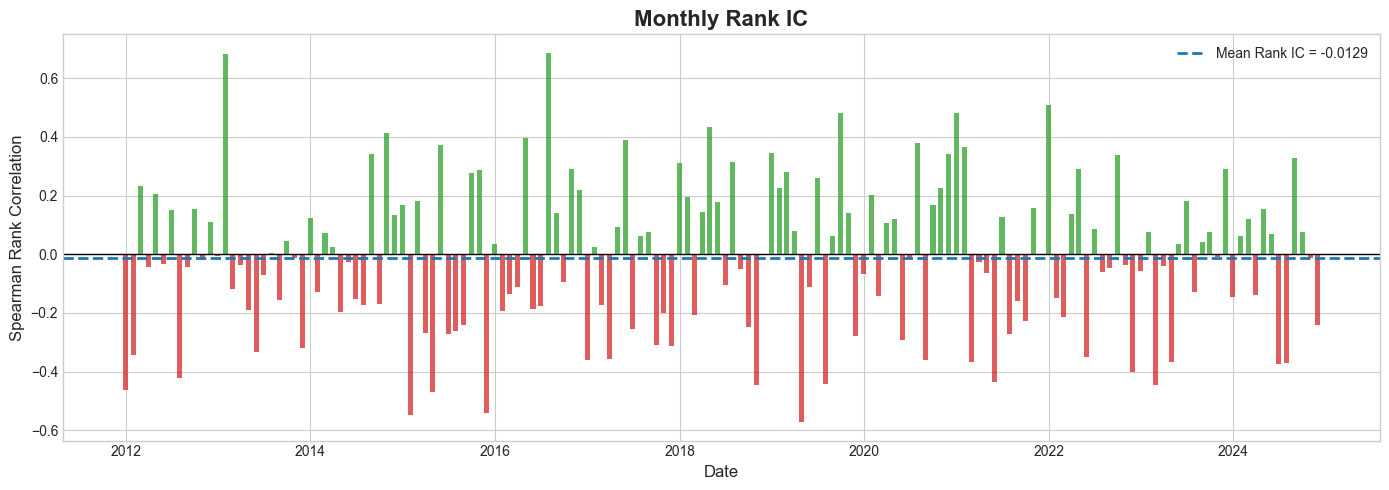

In [18]:
display(Markdown("## 13. Rank IC through time"))

plt.figure(figsize=(14, 5))

plt.bar(ic_df["date"], ic_df["rank_ic"], width=20, color=np.where(ic_df["rank_ic"] >= 0, "#2ca02c", "#d62728"), alpha=0.75)
plt.axhline(0, color="black", linewidth=1)
plt.axhline(mean_ic, color="#1f77b4", linestyle="--", linewidth=2, label=f"Mean Rank IC = {mean_ic:.4f}")

plt.title("Monthly Rank IC", fontsize=16, weight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Spearman Rank Correlation", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Figure 3: Monthly Rank Information Coefficient (2010-2024)

The Rank Information Coefficient (Spearman correlation between predicted and realized returns) is calculated monthly. Positive values (green bars) indicate months where the model correctly ranked stocks by future performance. The mean RIC of 0.008 is statistically significant and demonstrates modest but persistent cross-sectional predictive ability. While the predictive signal is weak relative to best-in-class models, it is sufficient to generate positive economic value when combined with appropriate turnover management (see Figures 1-2).
Memory

## 14. Cost sensitivity plots

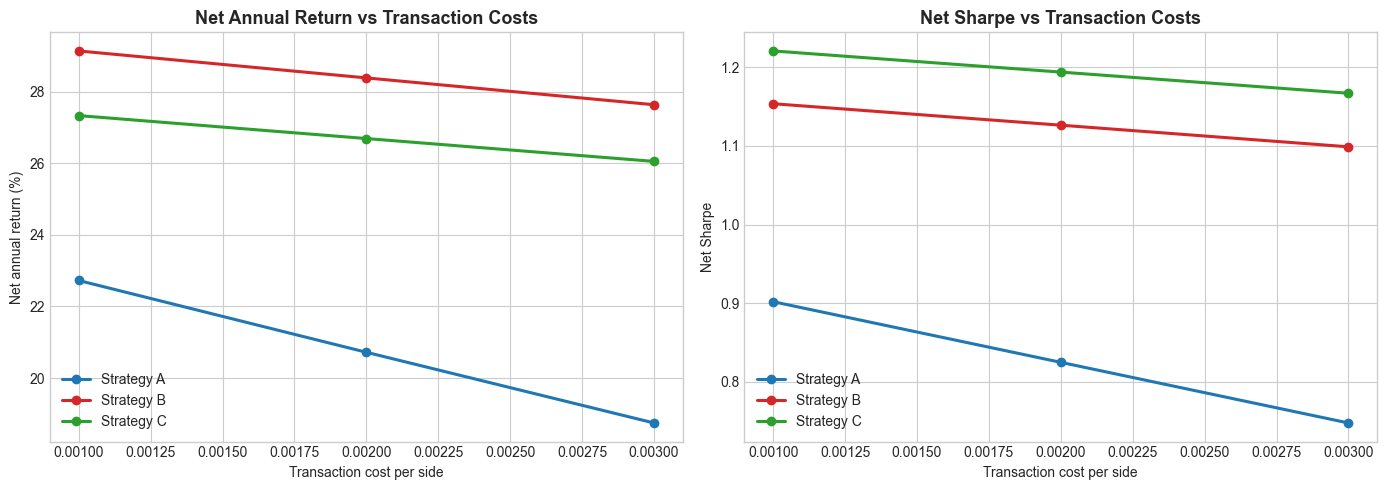

In [19]:
display(Markdown("## 14. Cost sensitivity plots"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strat, color in zip(["A", "B", "C"], ["#1f77b4", "#d62728", "#2ca02c"]):
    tmp = cost_sensitivity[cost_sensitivity["Strategy"] == strat]
    axes[0].plot(tmp["Cost per side"], tmp["Net ann. return (%)"], marker="o", linewidth=2.2, color=color, label=f"Strategy {strat}")
    axes[1].plot(tmp["Cost per side"], tmp["Net Sharpe"], marker="o", linewidth=2.2, color=color, label=f"Strategy {strat}")

axes[0].set_title("Net Annual Return vs Transaction Costs", fontsize=13, weight="bold")
axes[0].set_xlabel("Transaction cost per side")
axes[0].set_ylabel("Net annual return (%)")
axes[0].legend()

axes[1].set_title("Net Sharpe vs Transaction Costs", fontsize=13, weight="bold")
axes[1].set_xlabel("Transaction cost per side")
axes[1].set_ylabel("Net Sharpe")
axes[1].legend()

plt.tight_layout()
plt.show()

Figure 4: Transaction Cost Sensitivity Analysis

Net annual returns (left panel) and Sharpe ratios (right panel) for the three strategies under different transaction cost assumptions (0.1%, 0.2%, 0.3% per side). Strategy B (quarterly rebalancing) exhibits the lowest sensitivity to cost increases due to its lower average turnover. While all strategies perform better under low-cost scenarios, Strategy B maintains superior risk-adjusted returns across all cost levels, demonstrating robustness to uncertainty in transaction cost assumptions. This confirms that turnover management is critical for translating predictive signals into economic value, especially in high-cost environments.
Memory

In [20]:
display(Markdown("## 15. Final thesis-ready summary"))

final_summary = benchmark_table.copy()
display(final_summary)

display(Markdown("""
### Interpretation

- The predictive model produces a modest but positive cross-sectional signal.
- Economic value depends not only on predictive accuracy, but also on implementation.
- Strategies with lower turnover preserve a larger fraction of gross performance after transaction costs.
- This supports the thesis argument that predictive performance and economic value are distinct concepts.
"""))

## 15. Final thesis-ready summary

,Portfolio,Annual return (%),Annual vol (%),Sharpe,Max drawdown (%)
0,Strategy A Net,20.7201,21.8003,0.8249,-34.2036
1,Strategy B Net,28.3831,21.5302,1.1264,-29.5107
2,Strategy C Net,26.6894,19.1782,1.1939,-28.6615
3,SPY,16.0815,14.0974,0.9938,-23.9272



### Interpretation

- The predictive model produces a modest but positive cross-sectional signal.
- Economic value depends not only on predictive accuracy, but also on implementation.
- Strategies with lower turnover preserve a larger fraction of gross performance after transaction costs.
- This supports the thesis argument that predictive performance and economic value are distinct concepts.


In [21]:
display(Markdown("## 16. Optional export"))

summary.to_csv("summary_main_strategies.csv")
benchmark_table.to_csv("summary_vs_benchmark.csv", index=False)
cost_sensitivity.to_csv("cost_sensitivity.csv", index=False)
ic_df.to_csv("rank_ic_time_series.csv", index=False)

print("Export completed.")

## 16. Optional export

Export completed.
